In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("./bank-additional/bank-additional/bank-additional-full.csv",delimiter=";")
df.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [27]:
df = pd.DataFrame(df)

test = df['duration'].unique()
test = np.sort(test)
print(test)

[   0    1    2 ... 3785 4199 4918]


In [ ]:
allowed_y = {'yes', 'no'}
duration_simplified = (df['duration']/60).round()

if not set(df['y'].unique()).issubset(allowed_y):
    raise ValueError(
        f"Target column contains values outside {allowed_y}"
    )

# ------------------------------------------------------------------
# 3. Count the occurrences using a cross‑tabulation
# ------------------------------------------------------------------
job_target_counts = pd.crosstab(duration_simplified, df['y'])

print("Counts of ‘yes’ / ‘no’ per job category:")
job_target_counts = pd.DataFrame(job_target_counts)
job_target_counts

Counts of ‘yes’ / ‘no’ per job category:


y,no,yes
duration,,
0.0,1724,0
1.0,6620,44
2.0,8352,293
3.0,6133,461
4.0,4169,506
5.0,2682,400
6.0,1977,327
7.0,1274,291
8.0,921,262


In [29]:
job_target_percentages = (
    job_target_counts.div(job_target_counts.sum(axis=1), axis=0) * 100
).round(2)

print("\nPercentages of ‘yes’ / ‘no’ per job category:")
print(job_target_percentages)


Percentages of ‘yes’ / ‘no’ per job category:
y             no     yes
duration                
0.0       100.00    0.00
1.0        99.34    0.66
2.0        96.61    3.39
3.0        93.01    6.99
4.0        89.18   10.82
5.0        87.02   12.98
6.0        85.81   14.19
7.0        81.41   18.59
8.0        77.85   22.15
9.0        71.97   28.03
10.0       68.02   31.98
11.0       60.53   39.47
12.0       56.53   43.47
13.0       57.98   42.02
14.0       51.34   48.66
15.0       41.38   58.62
16.0       39.69   60.31
17.0       41.56   58.44
18.0       41.96   58.04
19.0       43.80   56.20
20.0       46.15   53.85
21.0       42.25   57.75
22.0       28.57   71.43
23.0       36.73   63.27
24.0       42.22   57.78
25.0       42.86   57.14
26.0       41.67   58.33
27.0       17.39   82.61
28.0       21.43   78.57
29.0       50.00   50.00
30.0       54.55   45.45
31.0       31.25   68.75
32.0       75.00   25.00
33.0       46.15   53.85
34.0       27.27   72.73
35.0       16.67   83.33
36.

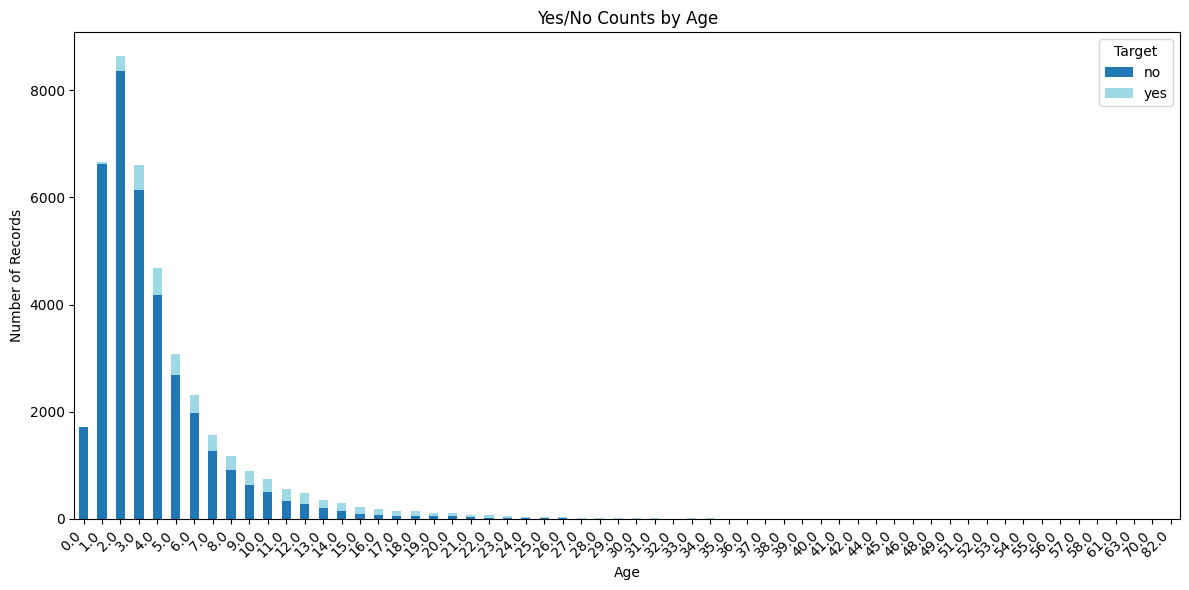

In [30]:
# ------------------------------------------------------------------
# 3a) Stacked bar chart (good if you want to compare totals)
# ------------------------------------------------------------------
ax = job_target_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    colormap='tab20',          # a nice palette for the two groups
)

plt.title('Yes/No Counts by Age')
plt.ylabel('Number of Records')
plt.xlabel('Age')
# Show legend title (optional)
ax.legend(title='Target')

# Optional: rotate x‑labels if ages are many or long
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### diatas merupakan waktu dalam menit

### ada 

Counts of ‘yes’ per duration category:
y         yes
duration     
0.0         0
1.0        44
2.0       293
3.0       461
4.0       506
5.0       400
6.0       327
7.0       291
8.0       262
9.0       250
10.0      237
11.0      223
12.0      213
13.0      150
14.0      145
15.0      136
16.0      117
17.0       90
18.0       83
19.0       68
20.0       56
21.0       41
22.0       50
23.0       31
24.0       26
25.0       20
26.0       21
27.0       19
28.0       11
29.0        7
30.0        5
31.0       11
32.0        1
33.0        7
34.0        8
35.0        5
36.0        2
37.0        2
38.0        2
39.0        0
40.0        2
41.0        4
42.0        1
44.0        2
45.0        2
46.0        1
48.0        0
49.0        1
51.0        1
52.0        1
53.0        1
54.0        0
55.0        0
56.0        0
57.0        0
58.0        0
61.0        2
63.0        0
70.0        1
82.0        0

Percentages of ‘yes’ per duration category:
y            yes
duration        
0.0         0.

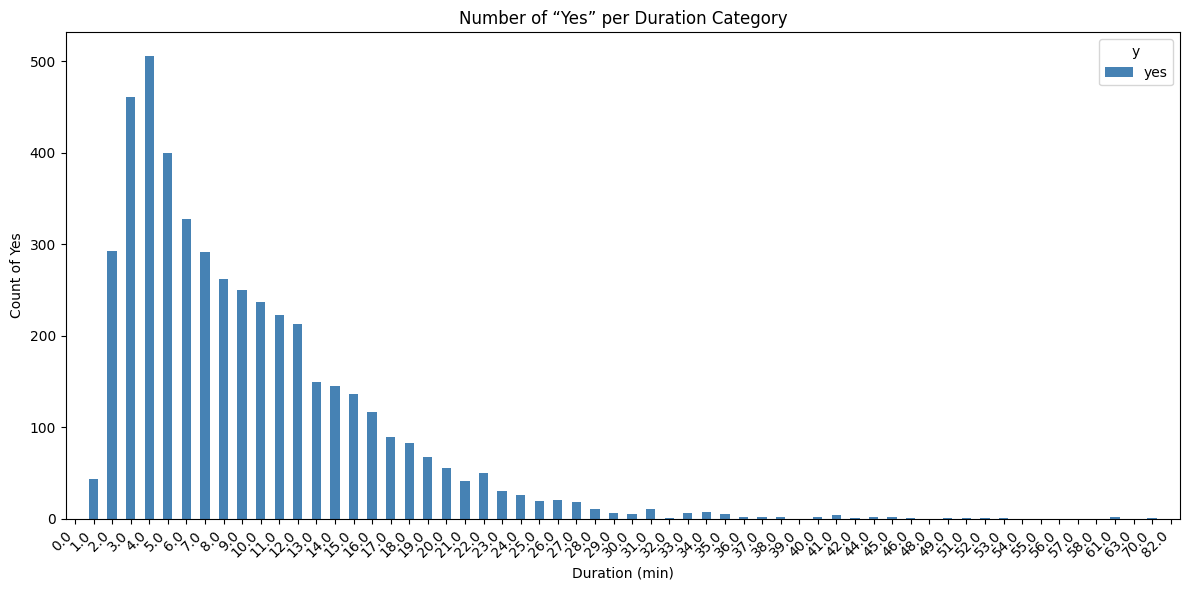

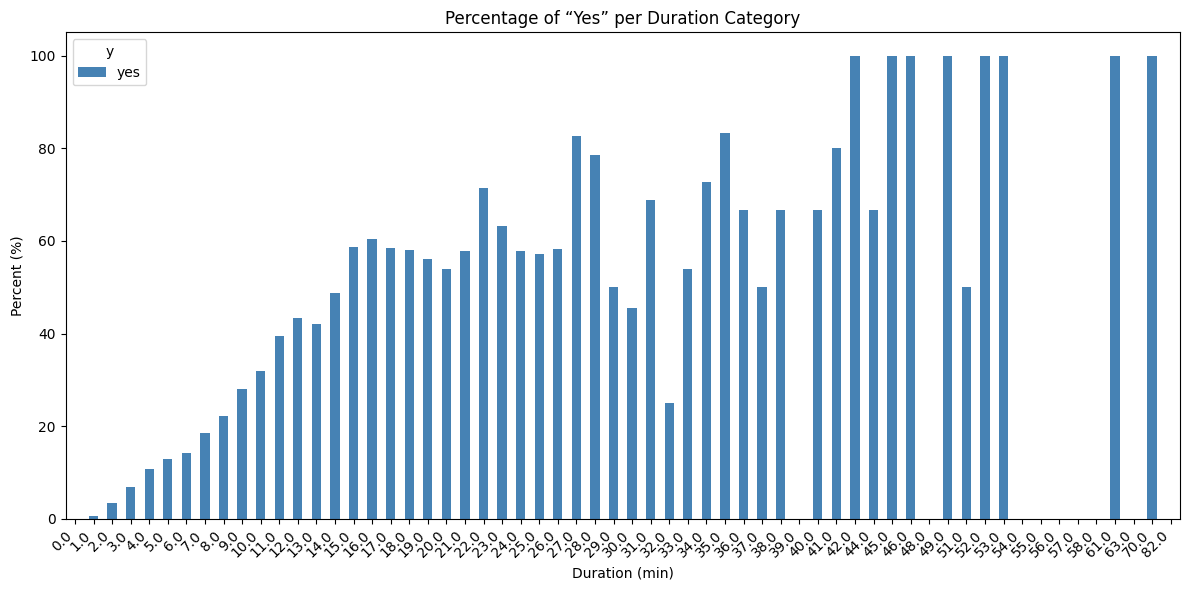

In [31]:
# ------------------------------------------------------------------
# 4️⃣ Keep only the 'yes' part of the tables
# ------------------------------------------------------------------

# --- Counts ---------------------------------------------------------
job_target_yes_counts = job_target_counts[['yes']]   # 1‑column DataFrame

print("Counts of ‘yes’ per duration category:")
print(job_target_yes_counts)

# --- Percentages ----------------------------------------------------
job_target_yes_percentages = job_target_percentages[['yes']]

print("\nPercentages of ‘yes’ per duration category:")
print(job_target_yes_percentages)

# ------------------------------------------------------------------
# 5️⃣ Optional: Plot just the 'yes' counts
# ------------------------------------------------------------------

ax = job_target_yes_counts.plot(
    kind='bar',
    figsize=(12, 6),
    color='steelblue',          # you can pick any palette you like
)

plt.title('Number of “Yes” per Duration Category')
plt.ylabel('Count of Yes')
plt.xlabel('Duration (min)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 6️⃣ If you prefer to see the percentages instead of raw counts:
# ------------------------------------------------------------------

ax = job_target_yes_percentages.plot(
    kind='bar',
    figsize=(12, 6),
    color='steelblue',
)

plt.title('Percentage of “Yes” per Duration Category')
plt.ylabel('Percent (%)')
plt.xlabel('Duration (min)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### optimal sampai 25 menit atau 26, sisanya mungkin bisa di hapus saja, karena outlier, jumlah konversi sedikit dan total orang juga sedikit